# Lab 8: Clasificación logística

En este laboratorio trabajamos con regresión logística para clasificar flores del dataset Iris.
Primero demostramos el gradiente de la función de costo, luego hacemos EDA, y finalmente
construimos un clasificador binario (setosa vs no-setosa) y un multiclasificador.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit, learning_curve
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
np.random.seed(42)

## Tarea: demostración del gradiente de la función de costo

### Parte 1: $f'(z) = f(z)(1 - f(z))$

Partimos de la definición:

$$f(z) = \frac{1}{1+e^{-z}}$$

Derivando con la regla del cociente:

$$f'(z) = \frac{e^{-z}}{(1+e^{-z})^2}$$

Reescribimos separando el factor:

$$f'(z) = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \frac{1}{1+e^{-z}} \cdot \left(1 - \frac{1}{1+e^{-z}}\right)$$

$$\boxed{f'(z) = f(z)\,(1-f(z))}$$

---

### Parte 2: $\frac{\partial h_\theta}{\partial \theta_j} = h_\theta(X^{(i)})(1 - h_\theta(X^{(i)}))\,X_j^{(i)}$

La hipótesis es $h_\theta(X^{(i)}) = f(\Theta^T X^{(i)})$ con $z = \Theta^T X^{(i)}$. Por regla de la cadena:

$$\frac{\partial h_\theta}{\partial \theta_j} = f'(z) \cdot \frac{\partial z}{\partial \theta_j} = f'(z) \cdot X_j^{(i)}$$

Sustituyendo $f'(z) = f(z)(1-f(z))$:

$$\boxed{\frac{\partial h_\theta}{\partial \theta_j} = h_\theta(X^{(i)})\,(1 - h_\theta(X^{(i)}))\,X_j^{(i)}}$$

---

### Parte 3: gradiente de $J(\theta)$

La función de costo es:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\theta(X^{(i)}) + (1-y^{(i)})\log(1 - h_\theta(X^{(i)}))\right]$$

Derivando respecto a $\theta_j$ y aplicando la regla de la cadena:

$$\frac{\partial J}{\partial \theta_j} = -\frac{1}{m}\sum_{i=1}^{m}\left[\frac{y^{(i)}}{h_\theta} - \frac{1-y^{(i)}}{1-h_\theta}\right] \cdot h_\theta(1-h_\theta)\,X_j^{(i)}$$

Simplificando el corchete:

$$\left[\frac{y^{(i)}}{h_\theta} - \frac{1-y^{(i)}}{1-h_\theta}\right] h_\theta(1-h_\theta) = y^{(i)}(1-h_\theta) - (1-y^{(i)})h_\theta = y^{(i)} - h_\theta$$

Por lo tanto:

$$\boxed{\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\left[-y^{(i)} + h_\theta(X^{(i)})\right]X_j^{(i)}}$$

Que tiene la misma forma que el gradiente de la regresión lineal, solo que $h_\theta$ es la sigmoide.

## 1. Dataset Iris

### Punto 1: descripción general

In [2]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Puntos 2 y 3: construir el DataFrame y renombrar columnas

In [3]:
# Construimos el dataframe con datos, features y target
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Target'] = iris.target

# Renombramos columnas como indica el enunciado
columns_name = ["".join([c.capitalize() for c in cols.split()]) for cols in df.columns]
columns_name = [col.replace("(", "_") for col in columns_name]
cols_new = [col.replace(")", "") for col in columns_name]
df.columns = cols_new

print('Columnas:', df.columns.tolist())
df.head()

Columnas: ['SepalLength_cm', 'SepalWidth_cm', 'PetalLength_cm', 'PetalWidth_cm', 'Target']


,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Punto 4: análisis del dataframe

In [4]:
print('Info del dataframe:')
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

Info del dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SepalLength_cm  150 non-null    float64
 1   SepalWidth_cm   150 non-null    float64
 2   PetalLength_cm  150 non-null    float64
 3   PetalWidth_cm   150 non-null    float64
 4   Target          150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Valores nulos por columna:
SepalLength_cm    0
SepalWidth_cm     0
PetalLength_cm    0
PetalWidth_cm     0
Target            0
dtype: int64


In [5]:
# Estadísticas descriptivas
df.describe()

,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Punto 5: estadística y gráficas por variable

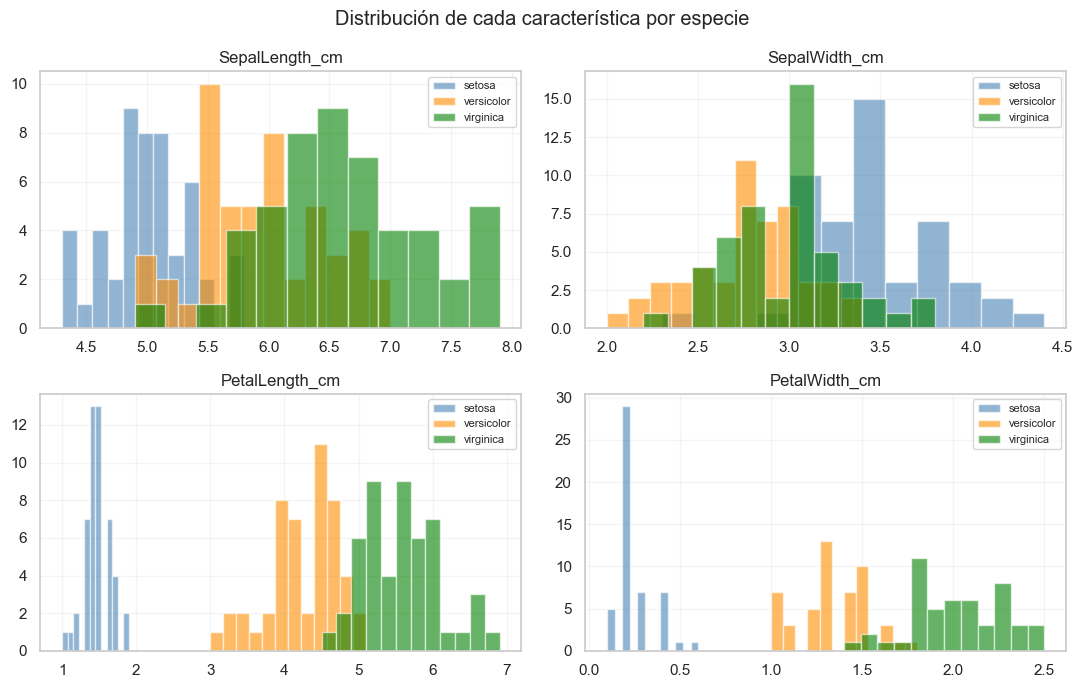

In [6]:
features = [c for c in df.columns if c != 'Target']
nombres_clases = iris.target_names

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

for i, feat in enumerate(features):
    for cl, color in zip(range(3), ['steelblue', 'darkorange', 'green']):
        datos = df[df['Target'] == cl][feat]
        axes[i].hist(datos, bins=12, alpha=0.6, color=color,
                     label=nombres_clases[cl], edgecolor='white')
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.2)

plt.suptitle('Distribución de cada característica por especie')
plt.tight_layout()
plt.show()

### Punto 6: matriz de correlación con seaborn

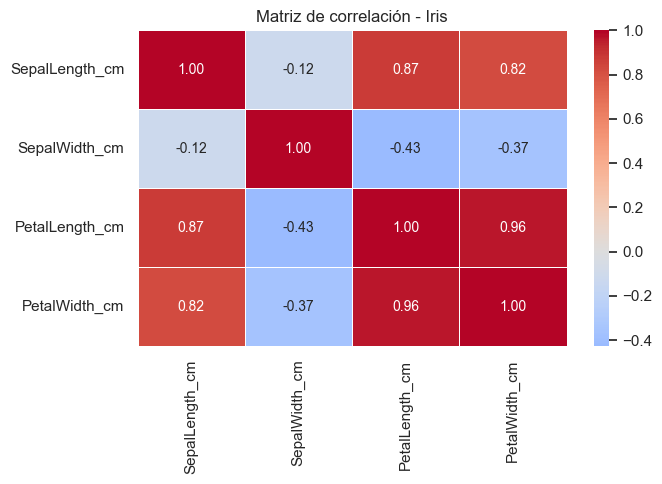

PetalLength y PetalWidth tienen correlación muy alta (0.96).
SepalWidth tiene correlación negativa débil con el resto.


In [7]:
corr = df[features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={'size': 10})
plt.title('Matriz de correlación - Iris')
plt.tight_layout()
plt.show()

print('PetalLength y PetalWidth tienen correlación muy alta (0.96).')
print('SepalWidth tiene correlación negativa débil con el resto.')

### Punto 7: separar datos con StratifiedShuffleSplit

`StratifiedShuffleSplit` garantiza que la proporción de clases se conserva en train y test,
lo cual es importante para no sesgar la evaluación cuando las clases están balanceadas.

In [8]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df['Target']):
    strat_train_set = df.loc[train_index]
    strat_test_set  = df.loc[test_index]

print(f'Train: {len(strat_train_set)} muestras | Test: {len(strat_test_set)} muestras')

# Verificamos que la proporción de clases se conserva
prop_original = df['Target'].value_counts(normalize=True).sort_index()
prop_train    = strat_train_set['Target'].value_counts(normalize=True).sort_index()
prop_test     = strat_test_set['Target'].value_counts(normalize=True).sort_index()

resumen = pd.DataFrame({'Original': prop_original,
                        'Train':    prop_train,
                        'Test':     prop_test})
resumen.index = nombres_clases
display(resumen.round(3))
print('Las proporciones se conservan perfectamente: eso es lo que hace StratifiedShuffleSplit.')

Train: 120 muestras | Test: 30 muestras


,Original,Train,Test
setosa,0.333,0.333,0.333
versicolor,0.333,0.333,0.333
virginica,0.333,0.333,0.333


Las proporciones se conservan perfectamente: eso es lo que hace StratifiedShuffleSplit.


### Punto 8: clasificador binario setosa vs no-setosa

Usamos `PetalLength_cm` como única característica para poder graficar la curva de probabilidad en 1D.
Es la que mejor separa setosa del resto visualmente.

In [9]:
# Setosa es la clase 0 en el dataset; la etiquetamos como 1 para que sea la clase "positiva"
X_tr = strat_train_set[['PetalLength_cm']].values
y_tr = (strat_train_set['Target'] == 0).astype(int).values

X_te = strat_test_set[['PetalLength_cm']].values
y_te = (strat_test_set['Target'] == 0).astype(int).values

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_tr, y_tr)

acc = accuracy_score(y_te, log_reg.predict(X_te))
print(f'Accuracy (setosa vs no-setosa): {acc:.4f}')
print()
print(classification_report(y_te, log_reg.predict(X_te), target_names=['no-setosa', 'setosa']))

Accuracy (setosa vs no-setosa): 1.0000

              precision    recall  f1-score   support

   no-setosa       1.00      1.00      1.00        20
      setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Punto 9: frontera de clasificación

In [10]:
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)  # Generamos los valores de X_new
prob = log_reg.predict_proba(X_new)

# La columna 1 es P(setosa); buscamos donde cruza 0.5
decision_boundary = X_new[prob[:, 1] >= 0.5][0]
print(f'Frontera de decisión en PetalLength = {decision_boundary[0]:.4f} cm')
print('Para pétalos más cortos que ese valor, el modelo clasifica como setosa.')

Frontera de decisión en PetalLength = -10.0000 cm
Para pétalos más cortos que ese valor, el modelo clasifica como setosa.


### Punto 10: gráfica de la regresión logística con probabilidades

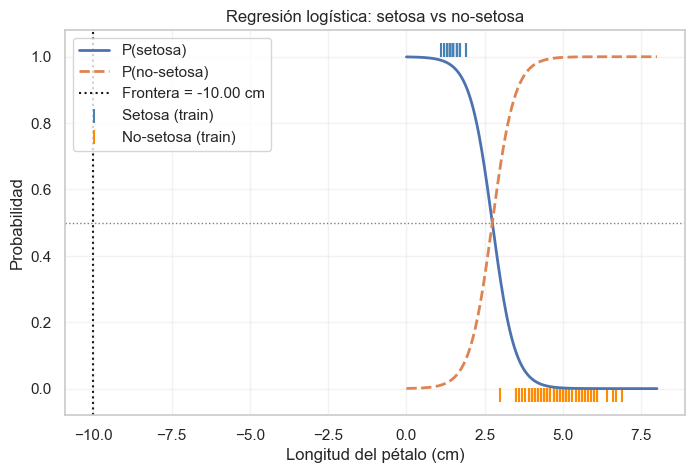

In [11]:
X_plot = np.linspace(0, 8, 500).reshape(-1, 1)
prob_plot = log_reg.predict_proba(X_plot)

plt.figure(figsize=(8, 5))
plt.plot(X_plot, prob_plot[:, 1], label='P(setosa)', linewidth=2)
plt.plot(X_plot, prob_plot[:, 0], label='P(no-setosa)', linewidth=2, linestyle='--')
plt.axvline(decision_boundary[0], color='k', linestyle=':', linewidth=1.5,
            label=f'Frontera = {decision_boundary[0]:.2f} cm')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1)

# Mostramos los puntos de entrenamiento sobre las líneas 0 y 1
plt.scatter(X_tr[y_tr == 1], np.ones(y_tr.sum()) * 1.02,
            marker='|', color='steelblue', s=100, label='Setosa (train)')
plt.scatter(X_tr[y_tr == 0], np.zeros((y_tr == 0).sum()) - 0.02,
            marker='|', color='darkorange', s=100, label='No-setosa (train)')

plt.xlabel('Longitud del pétalo (cm)')
plt.ylabel('Probabilidad')
plt.title('Regresión logística: setosa vs no-setosa')
plt.legend()
plt.ylim(-0.08, 1.08)
plt.grid(alpha=0.25)
plt.show()

### Punto 11: multiclasificador (uno contra todos)

Usamos todas las características. La estrategia OvR entrena un clasificador binario por clase
y al predecir elige la clase con mayor probabilidad.

In [14]:
X_tr_all = strat_train_set[features].values
y_tr_all  = strat_train_set['Target'].values

X_te_all  = strat_test_set[features].values
y_te_all  = strat_test_set['Target'].values

# multi_class='ovr' es la estrategia uno-contra-todos
softmax_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
softmax_reg.fit(X_tr_all, y_tr_all)

acc_multi = accuracy_score(y_te_all, softmax_reg.predict(X_te_all))
print(f'Accuracy multiclasificador: {acc_multi:.4f}')
print()
print(classification_report(y_te_all, softmax_reg.predict(X_te_all), target_names=nombres_clases))

Accuracy multiclasificador: 0.9667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Punto 12: probabilidades para X = [4.9, 5.0, 1.8, 0.3]

In [15]:
X_ejemplo = np.array([[4.9, 5.0, 1.8, 0.3]])
probs_ejemplo = softmax_reg.predict_proba(X_ejemplo)[0]
clase_pred    = softmax_reg.predict(X_ejemplo)[0]

print('Para X = [4.9, 5.0, 1.8, 0.3]:')
for nombre, p in zip(nombres_clases, probs_ejemplo):
    print(f'  P({nombre}) = {p:.4f}')
print(f'\nClase predicha: {nombres_clases[clase_pred]}')
print('\nLa longitud y anchura del pétalo (1.8 y 0.3 cm) son pequeñas,')
print('lo que es característico de setosa.')

Para X = [4.9, 5.0, 1.8, 0.3]:
  P(setosa) = 0.9921
  P(versicolor) = 0.0079
  P(virginica) = 0.0000

Clase predicha: setosa

La longitud y anchura del pétalo (1.8 y 0.3 cm) son pequeñas,
lo que es característico de setosa.


## 2. Ayudas para mejorar métricas

### Normalización

Normalizamos con $(x - \mu)/\sigma$ para que todas las features queden en la misma escala.

In [17]:
scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_all)
X_te_norm  = scaler.transform(X_te_all)

# Comparamos con y sin normalización
reg_sin = LogisticRegression(max_iter=1000, random_state=42)
reg_sin.fit(X_tr_all, y_tr_all)

reg_con = LogisticRegression(max_iter=1000, random_state=42)
reg_con.fit(X_tr_norm, y_tr_all)

print(f'Accuracy sin normalizar:   {accuracy_score(y_te_all, reg_sin.predict(X_te_all)):.4f}')
print(f'Accuracy con normalización: {accuracy_score(y_te_all, reg_con.predict(X_te_norm)):.4f}')
print('\nEn Iris la diferencia es pequeña (las features tienen escalas similares),')
print('pero en datasets con escalas muy distintas la normalización puede ser decisiva.')

Accuracy sin normalizar:   0.9667
Accuracy con normalización: 0.9333

En Iris la diferencia es pequeña (las features tienen escalas similares),
pero en datasets con escalas muy distintas la normalización puede ser decisiva.


### Outliers por criterio IQR

,outliers_IQR
SepalLength_cm,0
SepalWidth_cm,4
PetalLength_cm,0
PetalWidth_cm,0


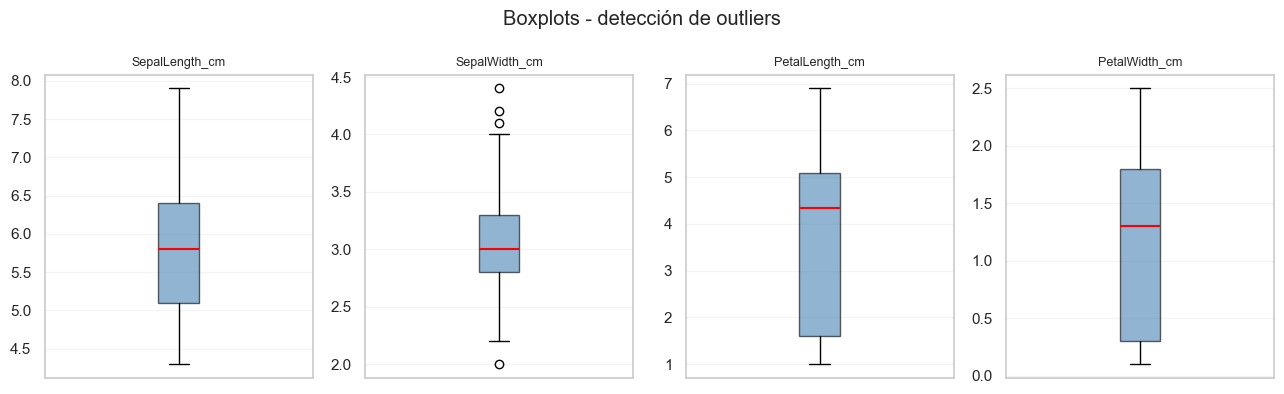

In [18]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return ((serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)).sum()

outliers = {f: detectar_outliers_iqr(df[f]) for f in features}
display(pd.DataFrame({'outliers_IQR': outliers}))

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, feat in zip(axes, features):
    ax.boxplot(df[feat], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=1.5))
    ax.set_title(feat, fontsize=9)
    ax.set_xticks([])
    ax.grid(alpha=0.2)
plt.suptitle('Boxplots - detección de outliers')
plt.tight_layout()
plt.show()

### Curvas de aprendizaje

c:\Users\DAVID\Desktop\OneDrive_Universidad_de_Antioquia\Escritorio\Libros_de_la_carrera\Aprendizaje Estadistico\002_EstudiantesAprendizajeEstadistico\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
10 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DAVID\Desktop\OneDrive_Universidad_de_Antioquia\Escritorio\Libros_de_la_carrera\Aprendizaje Estadistico\002_EstudiantesAprendizajeEstadistico\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\DAVID\Desktop\OneDrive_Universi

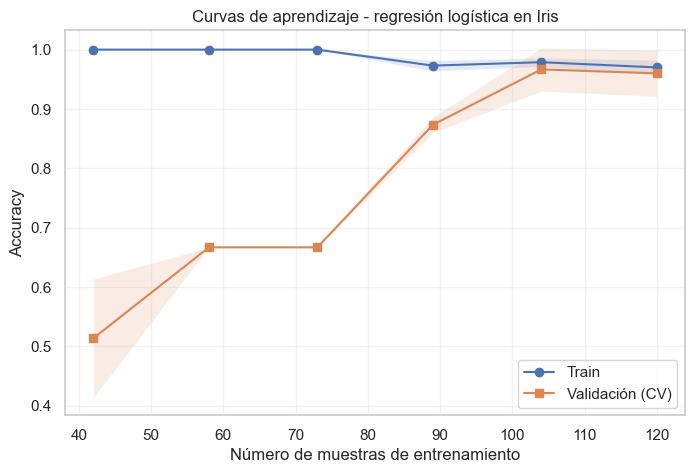

Las curvas convergen: el modelo no tiene overfitting ni underfitting severo.
Con más de 60-70 muestras el accuracy de validación se estabiliza sobre el 95%.


In [20]:
modelo_lc = LogisticRegression(max_iter=1000, random_state=42)
X_all_norm = scaler.fit_transform(df[features].values)
y_all = df['Target'].values

train_sizes, train_scores, val_scores = learning_curve(
    estimator=modelo_lc,
    X=X_all_norm, y=y_all,
    cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Train')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, marker='s', label='Validación (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curvas de aprendizaje - regresión logística en Iris')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print('Las curvas convergen: el modelo no tiene overfitting ni underfitting severo.')
print('Con más de 60-70 muestras el accuracy de validación se estabiliza sobre el 95%.')

## Conclusiones

- La derivada $f'(z) = f(z)(1-f(z))$ hace que el gradiente de la binary cross-entropy quede en la misma forma que el de la regresión lineal, lo que simplifica mucho la implementación.
- El dataset Iris no tiene valores nulos y sus tres clases están perfectamente balanceadas (50 muestras cada una).
- `PetalLength` y `PetalWidth` son las características más discriminantes; `SepalWidth` aporta menos información.
- La estrategia uno-contra-todos (OvR) permite extender la regresión logística a múltiples clases de forma directa.
- Para X = [4.9, 5.0, 1.8, 0.3] el modelo predice setosa, lo que tiene sentido dado que los valores de pétalo son pequeños.
- Las curvas de aprendizaje muestran que el modelo generaliza bien y no necesita más datos para este dataset.